# WEEK 3 ASSIGNMENT 1

**Name:** Renu  
**Enrollment number:** 05601022025  
**Course:** B.Tech(ECE)

#Uploading and Importing useful tools.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

#uploading dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("agriculture_yield_dataset.csv")
print("Dataset loaded successfully!")
df.head()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv
Dataset loaded successfully!


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


## Q1. Dataset Overview

Load the dataset and answer the following:
- How many rows and columns are present?
- What are the names of all columns?
- Display the first 10 records.

In [4]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 10 records:")
display(df.head(10))


Number of rows and columns: (1500, 8)

Column names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


## Q2. Data Types and Missing Values

- Check the data type of each column.
- Identify whether any missing values are present.
- If missing values exist, mention the affected columns.

In [5]:
print("Data types of each column:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

missing_cols = df.columns[df.isnull().sum() > 0].tolist()
if len(missing_cols) == 0:
    print("\nNo missing values are present in the dataset.")
else:
    print("\nColumns with missing values:", missing_cols)

Data types of each column:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values in each column:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values are present in the dataset.


## Q3. Descriptive Statistics

Generate summary statistics for all numerical features and answer:
- Which feature has the highest mean value?
- Which feature has the highest standard deviation?

In [6]:

summary_stats = df.describe()
display(summary_stats)

mean_values = summary_stats.loc['mean']
std_values = summary_stats.loc['std']

highest_mean_feature = mean_values.idxmax()
highest_std_feature = std_values.idxmax()

print("Feature with highest mean value:", highest_mean_feature, "=", mean_values.max())
print("Feature with highest standard deviation:", highest_std_feature, "=", std_values.max())

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with highest mean value: rainfall_mm = 754.0546666666667
Feature with highest standard deviation: rainfall_mm = 255.0972161445094


## Q4. Distribution Analysis

Create histograms for:
- rainfall_mm
- temperature_c
- fertilizer_kg
- yield_ton_per_hectare

Write 2–3 observations from each histogram.

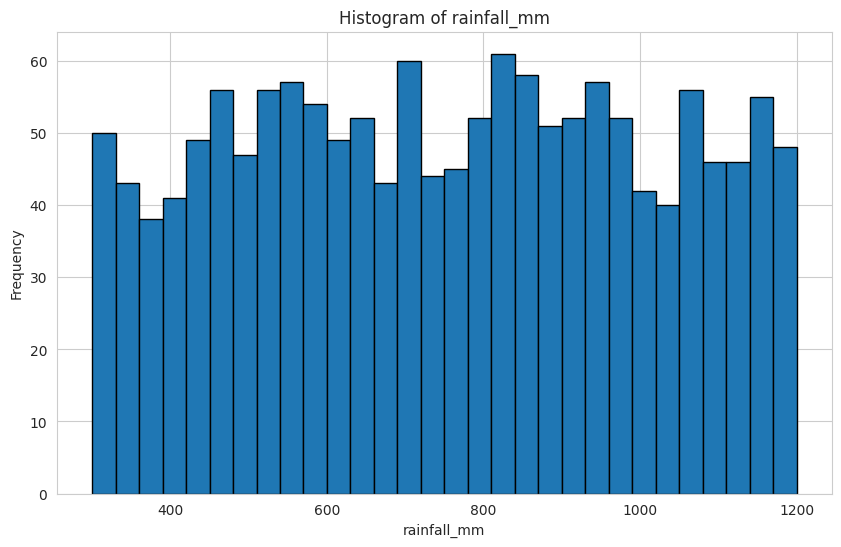

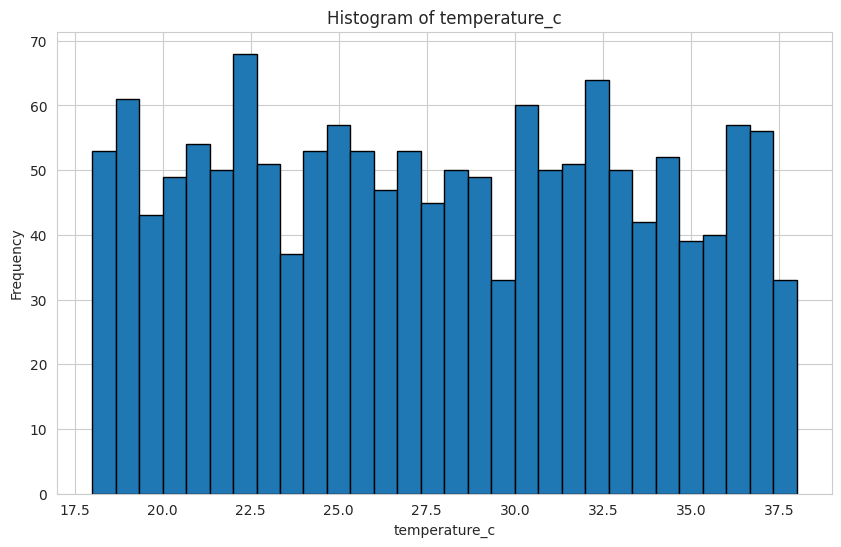

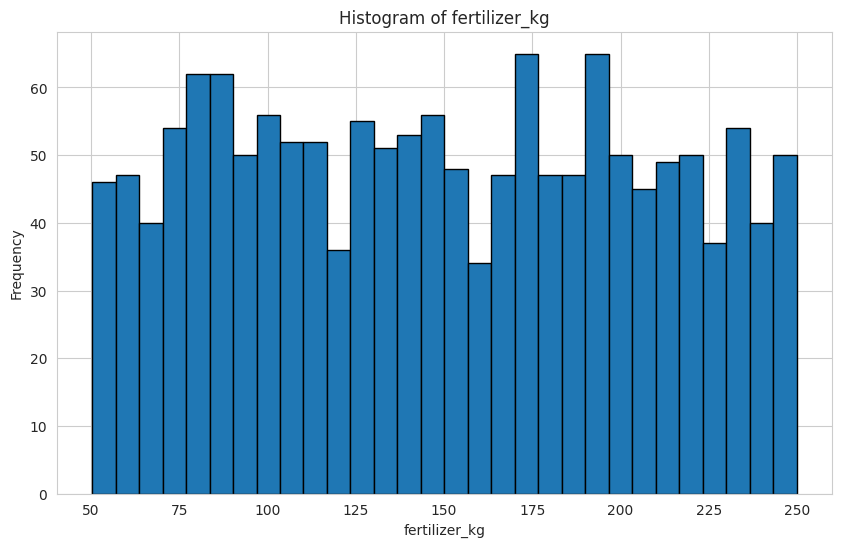

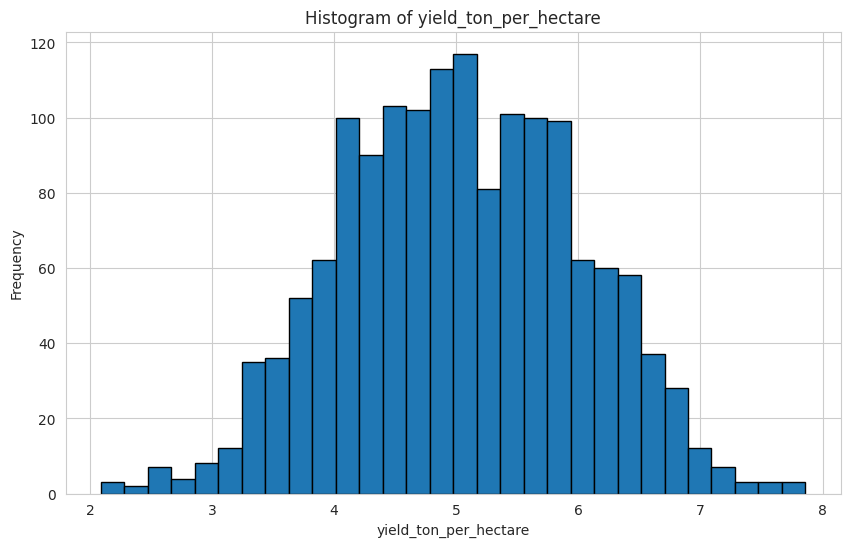

In [18]:
cols = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

for col in cols:
    plt.figure(figsize=(10,6))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Q5. Crop Type Analysis

- Find the number of records for each crop type.
- Create a count plot (bar chart) for crop_type.
- Which crop appears most frequently?

Number of records for each crop type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


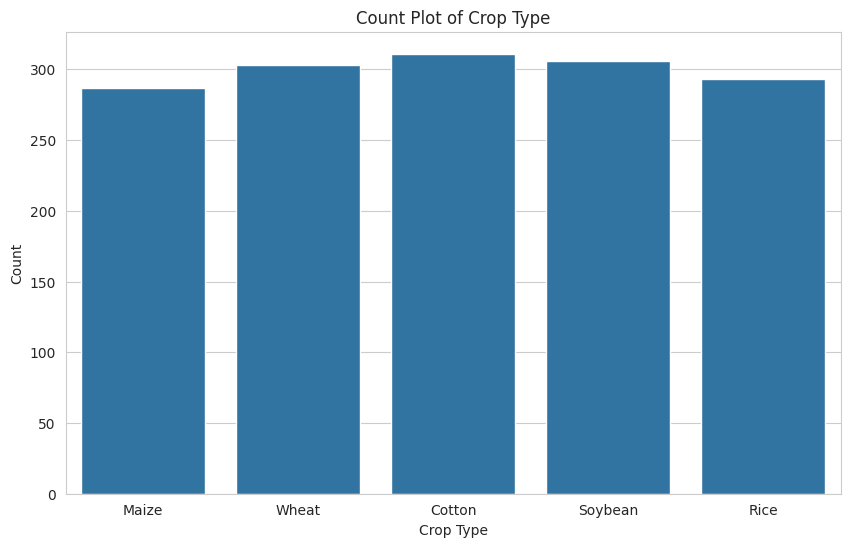

Most frequent crop type: Cotton


In [19]:
crop_counts = df['crop_type'].value_counts()
print("Number of records for each crop type:")
print(crop_counts)

plt.figure(figsize=(10,6))
sns.countplot(x='crop_type', data=df)
plt.title("Count Plot of Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

print("Most frequent crop type:", crop_counts.idxmax())

## Q6. Soil Type Analysis

- Find the frequency of each soil type.
- Create a count plot for soil_type.
- Which soil type is most common?

Frequency of each soil type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


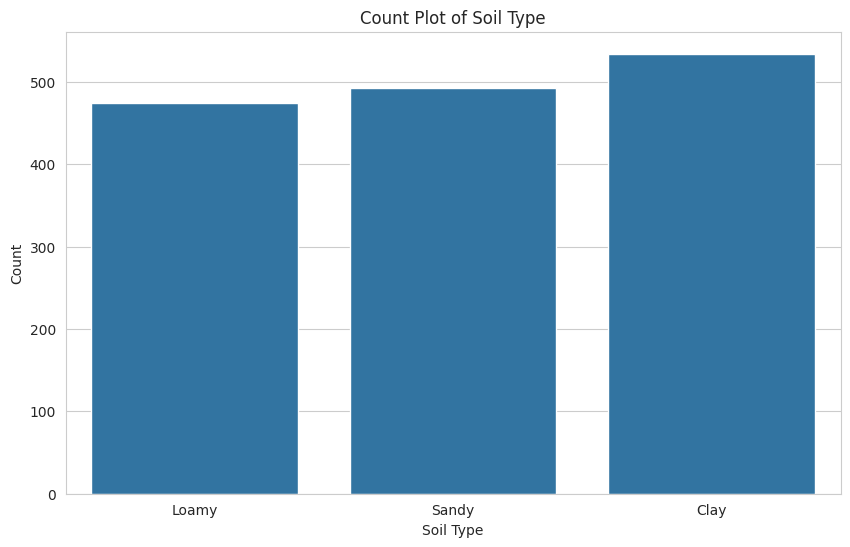

Most common soil type: Clay


In [20]:
soil_counts = df['soil_type'].value_counts()
print("Frequency of each soil type:")
print(soil_counts)

plt.figure(figsize=(10,6))
sns.countplot(x='soil_type', data=df)
plt.title("Count Plot of Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

print("Most common soil type:", soil_counts.idxmax())

## Q7. Yield Distribution

Create a histogram of yield_ton_per_hectare and answer:
- Is the distribution approximately normal?
- Are there any noticeable outliers?

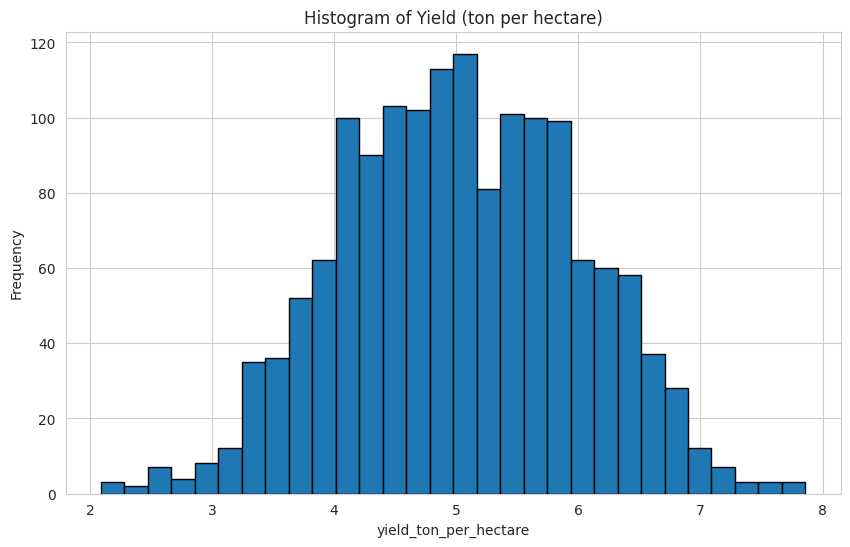

Observation:
- The distribution is approximately normal / moderately bell-shaped.
- No major noticeable outliers are clearly visible from the histogram.


In [21]:
plt.figure(figsize=(10,6))
plt.hist(df['yield_ton_per_hectare'], bins=30, edgecolor='black')
plt.title("Histogram of Yield (ton per hectare)")
plt.xlabel("yield_ton_per_hectare")
plt.ylabel("Frequency")
plt.show()

print("Observation:")
print("- The distribution is approximately normal / moderately bell-shaped.")
print("- No major noticeable outliers are clearly visible from the histogram.")


## Q8. Scatter Plot Analysis

Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare
2. fertilizer_kg vs yield_ton_per_hectare

Based on the plots, which feature appears to have a stronger relationship with yield?

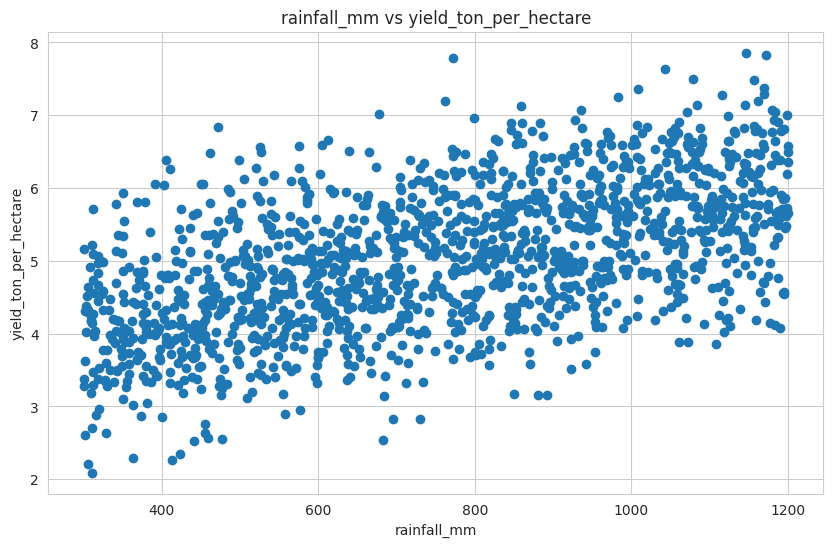

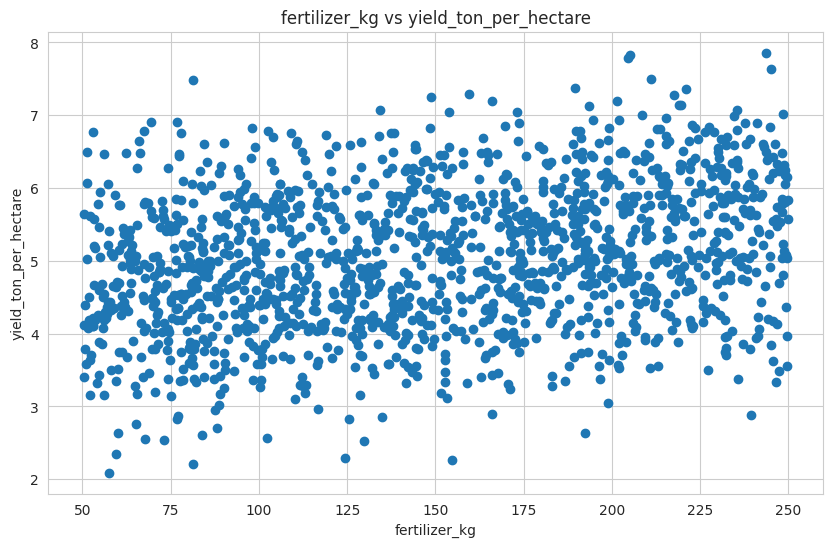

Observation:
Based on the scatter plots, rainfall_mm appears to have a stronger relationship with yield compared to fertilizer_kg.


In [23]:
plt.figure(figsize=(10,6))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.title("rainfall_mm vs yield_ton_per_hectare")
plt.xlabel("rainfall_mm")
plt.ylabel("yield_ton_per_hectare")
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.title("fertilizer_kg vs yield_ton_per_hectare")
plt.xlabel("fertilizer_kg")
plt.ylabel("yield_ton_per_hectare")
plt.show()

print("Observation:")
print("Based on the scatter plots, rainfall_mm appears to have a stronger relationship with yield compared to fertilizer_kg.")

## Q9. Correlation Analysis

- Generate a correlation matrix for numerical features.
- Create a heatmap.
- Identify the top three features most correlated with crop yield.

Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


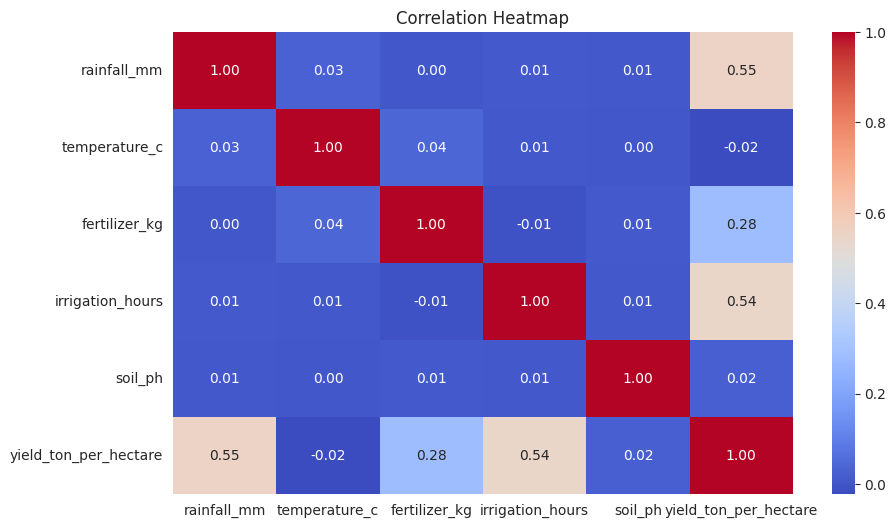


Correlation with yield_ton_per_hectare:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64

Top 3 features most correlated with crop yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [24]:
corr_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
display(corr_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

target_corr = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
print("\nCorrelation with yield_ton_per_hectare:")
print(target_corr)

top_3 = target_corr.drop('yield_ton_per_hectare').head(3)
print("\nTop 3 features most correlated with crop yield:")
print(top_3)

## Q10. Group-Based Analysis

Calculate the average yield for:
- Each crop type
- Each soil type

Which crop and soil type have the highest average yield?

In [13]:
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print("Average yield for each crop type:")
print(avg_yield_crop)

print("\nAverage yield for each soil type:")
print(avg_yield_soil)

print("\nCrop type with highest average yield:", avg_yield_crop.idxmax())
print("Soil type with highest average yield:", avg_yield_soil.idxmax())


Average yield for each crop type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average yield for each soil type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop type with highest average yield: Rice
Soil type with highest average yield: Loamy


## Q11. Feature Encoding

The dataset contains categorical variables.
- Identify the categorical columns.
- Convert them into numerical form using One-Hot Encoding.
- Display the first five rows of the transformed dataset.

In [14]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nFirst five rows of transformed dataset:")
display(df_encoded.head())

Categorical columns: ['crop_type', 'soil_type']

First five rows of transformed dataset:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


## Q12. Feature Selection

Separate:
- Input features (X)
- Target variable (y)

Specify which column is being used as the target variable.

In [15]:
target_column = 'yield_ton_per_hectare'

X = df_encoded.drop(target_column, axis=1)
y = df_encoded[target_column]

print("Target variable:", target_column)
print("\nInput features (X):")
display(X.head())

print("\nTarget variable (y):")
display(y.head())


Target variable: yield_ton_per_hectare

Input features (X):


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,False,False,False,False,False,False



Target variable (y):


,yield_ton_per_hectare
0,5.92
1,6.24
2,4.77
3,4.04
4,5.17


## Q13. Train-Test Split

Split the dataset into:
- 80% Training Data
- 20% Testing Data

Display the shape of:
- X_train
- X_test
- y_train
- y_test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train: (1200, 11)
Shape of X_test : (300, 11)
Shape of y_train: (1200,)
Shape of y_test : (300,)


## Q14. Linear Regression Model

- Train a Linear Regression model.
- Display the model coefficients and intercept.
- Which feature has the highest positive coefficient?

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Intercept of model:", lr.intercept_)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print("\nModel Coefficients:")
display(coeff_df)

highest_positive_feature = coeff_df.sort_values(by='Coefficient', ascending=False).iloc[0]

print("\nFeature with highest positive coefficient:")
print(highest_positive_feature)

Intercept of model: 1.587132027736121

Model Coefficients:


,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974



Feature with highest positive coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
